# FixMatch Label-Fraction Sweep on STL-10

Trains FixMatch at label fractions of 4 / 10 / 25 / 100 / 500 per class with:
- **Random init** — standard FixMatch baseline
- **SimCLR init** — encoder from `simclr_pretrain.ipynb` (if checkpoint exists)

Produces a label efficiency curve and exports the best model to ONNX.

**Full run** (~90 min on Kaggle T4): `SMOKE_TEST = False`  
**Quick sanity check** (~3 min, CPU/low-disk): `SMOKE_TEST = True`

## Actual results (Kaggle T4, 200 epochs FixMatch / 100 epochs supervised)

| Method | Labels / class | Total labels | Test accuracy |
|---|---|---|---|
| Supervised baseline | 500 | 5,000 | **55.9%** |
| FixMatch (random init) | 4 | 40 | 10.3% |
| FixMatch (random init) | 10 | 100 | 10.0% |
| FixMatch (random init) | 25 | 250 | 10.0% |
| FixMatch (random init) | 100 | 1,000 | **41.6%** |
| FixMatch (random init) | 500 | 5,000 | **61.8%** |
| SimCLR + FixMatch | — | — | not run (SimCLR ckpt in separate session) |

> **Note**: FixMatch with ≤25 labels/class scores ~10% (near-random) because the
> pseudo-label confidence threshold (0.95) is never met with a randomly-initialised
> encoder and so few labelled examples — the unsupervised loss contributes nothing.
> Performance recovers at 100 labels/class (41.6%) where pseudo-labels start
> activating. Re-running with the SimCLR encoder should raise low-label accuracy
> significantly (expected ~60–70% at 25 labels/class).

In [1]:
from kaggle_secrets import UserSecretsClient

token = UserSecretsClient().get_secret("GITHUB_TOKEN")
!git clone https://{token}@github.com/dima806/semi_supervised_image_clf.git

Cloning into 'semi_supervised_image_clf'...
remote: Enumerating objects: 105, done.
remote: Counting objects: 100% (105/105), done.
remote: Compressing objects: 100% (74/74), done.
remote: Total 105 (delta 36), reused 85 (delta 24), pack-reused 0 (from 0)
Receiving objects: 100% (105/105), 376.41 KiB | 4.76 MiB/s, done.
Resolving deltas: 100% (36/36), done.


In [2]:
!pip install --no-deps git+https://{token}@github.com/dima806/semi_supervised_image_clf.git

  Cloning https://****@github.com/dima806/semi_supervised_image_clf.git to /tmp/pip-req-build-rguxawvc
  Running command git clone --filter=blob:none --quiet 'https://****@github.com/dima806/semi_supervised_image_clf.git' /tmp/pip-req-build-rguxawvc
  Resolved https://****@github.com/dima806/semi_supervised_image_clf.git to commit 3fbb6da37406e2cca95a3f3a61c43956a3da9b49
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for semi-supervised-image-clf: filename=semi_supervised_image_clf-0.1.0-py3-none-any.whl size=27268 sha256=3a8044e9689f7e369f9ca9158e9d89658a9989f769ae6239afb7c01826b3727a
  Stored in directory: /tmp/pip-ephem-wheel-cache-lp3oocey/wheels/cf/26/7d/5d2cba3c00f664a1ba559afa231865f6ce72885510d0f7f109
Successfully built semi-supervised-image-clf


In [3]:
!pip install mlflow loguru torchvision onnxruntime onnxscript

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 70.9 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 96.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 65.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 85.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━

In [5]:
# Disable MLflow tracking globally (affects all internal training calls)
import mlflow

class _NoOpRun:
    def __enter__(self): return self
    def __exit__(self, *a): pass

mlflow.set_experiment = lambda *a, **kw: None
mlflow.start_run     = lambda *a, **kw: _NoOpRun()
mlflow.log_params    = lambda *a, **kw: None
mlflow.log_param     = lambda *a, **kw: None
mlflow.log_metric    = lambda *a, **kw: None
mlflow.log_metrics   = lambda *a, **kw: None
mlflow.end_run       = lambda *a, **kw: None
print('MLflow tracking disabled.')

MLflow tracking disabled.


In [6]:
import torch
print(f'torch version:    {torch.__version__}')
print(f'CUDA available:   {torch.cuda.is_available()}')
if torch.cuda.is_available():
    cc = torch.cuda.get_device_capability()
    print(f'GPU:              {torch.cuda.get_device_name(0)}')
    print(f'Compute cap:      sm_{cc[0]}{cc[1]}')
    # Verify a kernel actually runs on this device
    try:
        x = torch.ones(4, 4).cuda()
        _ = torch.nn.BatchNorm1d(4).cuda()(x)
        print('Kernel smoke test: PASSED')
    except Exception as e:
        print(f'Kernel smoke test: FAILED — {e}')

torch version:    2.10.0+cu128
CUDA available:   True
GPU:              Tesla T4
Compute cap:      sm_75
Kernel smoke test: PASSED


## 1. Configuration

In [7]:
# ── Set to True for a fast local sanity-check (uses < 300 MB of data) ──────
SMOKE_TEST = False # True
# ────────────────────────────────────────────────────────────────────────────

DATA_DIR       = '/kaggle/working/data/'
CHECKPOINT_DIR = '/kaggle/working/checkpoints/'
PLOTS_DIR      = '/kaggle/working/plots/'
SIMCLR_CKPT    = f'{CHECKPOINT_DIR}simclr_encoder.pt'

# Smoke-test caps (ignored when SMOKE_TEST = False)
SMOKE_MAX_LABELLED   = 200
SMOKE_MAX_UNLABELLED = 500
SMOKE_EPOCHS_FM      = 2
SMOKE_EPOCHS_SUP     = 2
SMOKE_LABELS_SWEEP   = [25]

FULL_LABELS_SWEEP = [4, 10, 25, 100, 500]
LABELS_PER_CLASS  = SMOKE_LABELS_SWEEP if SMOKE_TEST else FULL_LABELS_SWEEP

print(f'SMOKE_TEST = {SMOKE_TEST}')
print(f'Label fractions: {LABELS_PER_CLASS}')

SMOKE_TEST = False
Label fractions: [4, 10, 25, 100, 500]


## 2. Environment setup

In [8]:
import subprocess, sys
print(subprocess.run(['nvidia-smi'], capture_output=True, text=True).stdout or 'No GPU.')
print('Environment ready.')

Mon Apr  6 18:25:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P0             27W /   70W |     123MiB /  15360MiB |      2%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [9]:
import json
from pathlib import Path

import torch
from torch.utils.data import DataLoader
from torchvision import datasets

from semi_supervised_image_clf.config import load_fixmatch_config, load_supervised_config
from semi_supervised_image_clf.dataset import get_stl10_splits
from semi_supervised_image_clf.evaluate import evaluate
from semi_supervised_image_clf.export import export_onnx
from semi_supervised_image_clf.fixmatch import FixMatchUnlabelledDataset, train_fixmatch
from semi_supervised_image_clf.model import ResNet18Classifier
from semi_supervised_image_clf.plot import plot_label_efficiency_curve
from semi_supervised_image_clf.supervised import train_supervised

for d in [DATA_DIR, CHECKPOINT_DIR, PLOTS_DIR]:
    Path(d).mkdir(parents=True, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}' + (f'  GPU: {torch.cuda.get_device_name(0)}' if DEVICE == 'cuda' else ''))
simclr_available = Path(SIMCLR_CKPT).exists()
print(f'SimCLR checkpoint available: {simclr_available}')

Device: cuda  GPU: Tesla T4
SimCLR checkpoint available: False


## 3. Load config

In [10]:
fm_cfg  = load_fixmatch_config('semi_supervised_image_clf/config/fixmatch.yaml')
sup_cfg = load_supervised_config('semi_supervised_image_clf/config/supervised.yaml')

fm_cfg.data.data_dir  = DATA_DIR
sup_cfg.data.data_dir = DATA_DIR

if SMOKE_TEST:
    fm_cfg.training.epochs   = SMOKE_EPOCHS_FM
    sup_cfg.training.epochs  = SMOKE_EPOCHS_SUP
    fm_cfg.data.num_workers  = 2
    sup_cfg.data.num_workers = 2
else:
    fm_cfg.training.epochs   = 200
    sup_cfg.training.epochs  = 100
    fm_cfg.data.num_workers  = 4
    sup_cfg.data.num_workers = 4

INPUT_SIZE  = fm_cfg.model.input_size
NUM_CLASSES = fm_cfg.model.num_classes
SEED        = fm_cfg.data.random_seed
print(f'Input: {INPUT_SIZE}x{INPUT_SIZE}  Classes: {NUM_CLASSES}  Epochs: {fm_cfg.training.epochs}')

Input: 64x64  Classes: 10  Epochs: 200


## 4. Download data

In [11]:
# train (~120 MB) and test (~190 MB) are always needed.
# unlabelled (~2.5 GB) is only downloaded in full-run mode;
# in smoke mode it downloads once but only the first SMOKE_MAX_UNLABELLED images are used.
print('Downloading STL-10 train + test splits...')
for split in ('train', 'test'):
    ds = datasets.STL10(root=DATA_DIR, split=split, download=True)
    print(f'  {split}: {len(ds):,} images')

print('Downloading STL-10 unlabelled split...')
ds_unlab = datasets.STL10(root=DATA_DIR, split='unlabeled', download=True)
n_unlab = SMOKE_MAX_UNLABELLED if SMOKE_TEST else len(ds_unlab)
print(f'  unlabelled: using {n_unlab:,} of {len(ds_unlab):,} images')

100%|██████████| 2.64G/2.64G [08:26<00:00, 5.22MB/s] 


  train: 5,000 images
  test: 8,000 images
  unlabelled: using 100,000 of 100,000 images


## 5. Supervised baseline

In [12]:
sup_cfg.data.labels_per_class = 500
labelled_loader, _, test_loader = get_stl10_splits(
    config=sup_cfg.data, labels_per_class=500, seed=SEED, input_size=INPUT_SIZE,
    smoke_test=SMOKE_TEST,
    max_labelled=SMOKE_MAX_LABELLED,
    max_unlabelled=SMOKE_MAX_UNLABELLED,
)
model_sup = train_supervised(
    ResNet18Classifier(num_classes=NUM_CLASSES),
    labelled_loader, test_loader, sup_cfg, CHECKPOINT_DIR,
)
acc_sup = evaluate(model_sup, test_loader).accuracy
print(f'Supervised baseline accuracy: {acc_sup:.4f}')

2026-04-06 18:35:03.531 | INFO     | semi_supervised_image_clf.dataset:get_stl10_splits:279 - Dataset splits — labelled: 5000, unlabelled: 100000, test: 8000
2026-04-06 18:35:09.989 | INFO     | semi_supervised_image_clf.supervised:train_supervised:108 - Supervised epoch 1/100 — loss: 1.8163  acc: 0.4036
2026-04-06 18:35:15.049 | INFO     | semi_supervised_image_clf.supervised:train_supervised:108 - Supervised epoch 2/100 — loss: 1.3609  acc: 0.4531
2026-04-06 18:35:20.072 | INFO     | semi_supervised_image_clf.supervised:train_supervised:108 - Supervised epoch 3/100 — loss: 1.0187  acc: 0.4462
2026-04-06 18:35:25.090 | INFO     | semi_supervised_image_clf.supervised:train_supervised:108 - Supervised epoch 4/100 — loss: 0.7131  acc: 0.4474
2026-04-06 18:35:30.096 | INFO     | semi_supervised_image_clf.supervised:train_supervised:108 - Supervised epoch 5/100 — loss: 0.4621  acc: 0.4868
2026-04-06 18:35:35.241 | INFO     | semi_supervised_image_clf.supervised:train_supervised:108 - Super

Supervised baseline accuracy: 0.5586


## 6. FixMatch label-fraction sweep

In [13]:
results: dict[str, dict[int, float]] = {
    'Supervised':        {500 * NUM_CLASSES: acc_sup},
    'FixMatch':          {},
    'SimCLR + FixMatch': {},
}

for n in LABELS_PER_CLASS:
    total = n * NUM_CLASSES
    print(f'\n--- labels_per_class={n}  (total={total}) ---')

    fm_cfg.data.labels_per_class = n
    labelled_loader, unlabelled_base, test_loader = get_stl10_splits(
        config=fm_cfg.data, labels_per_class=n, seed=SEED, input_size=INPUT_SIZE,
        smoke_test=SMOKE_TEST,
        max_labelled=SMOKE_MAX_LABELLED,
        max_unlabelled=SMOKE_MAX_UNLABELLED,
    )
    unlabelled_loader = DataLoader(
        FixMatchUnlabelledDataset(unlabelled_base.dataset, input_size=INPUT_SIZE),
        batch_size=32 if SMOKE_TEST else fm_cfg.training.batch_size_unlabelled,
        shuffle=True,
        num_workers=fm_cfg.data.num_workers,
        pin_memory=(DEVICE == 'cuda'),
        drop_last=True,
    )

    # FixMatch — random init
    fm_cfg.model.pretrained_simclr = None
    model_fm = train_fixmatch(
        ResNet18Classifier(num_classes=NUM_CLASSES),
        labelled_loader, unlabelled_loader, fm_cfg, CHECKPOINT_DIR,
        run_name=f'fixmatch_n{n}',
    )
    results['FixMatch'][total] = evaluate(model_fm, test_loader).accuracy
    print(f'  FixMatch:          {results["FixMatch"][total]:.4f}')

    # SimCLR + FixMatch
    if simclr_available:
        model_ssl = ResNet18Classifier(num_classes=NUM_CLASSES)
        model_ssl.encoder.load_state_dict(torch.load(SIMCLR_CKPT, map_location='cpu'))
        fm_cfg.model.pretrained_simclr = SIMCLR_CKPT
        model_ssl = train_fixmatch(
            model_ssl, labelled_loader, unlabelled_loader, fm_cfg, CHECKPOINT_DIR,
            run_name=f'simclr+fixmatch_n{n}',
        )
        results['SimCLR + FixMatch'][total] = evaluate(model_ssl, test_loader).accuracy
        print(f'  SimCLR + FixMatch: {results["SimCLR + FixMatch"][total]:.4f}')

print('\nSweep complete.')


--- labels_per_class=4  (total=40) ---


2026-04-06 18:43:30.574 | INFO     | semi_supervised_image_clf.dataset:get_stl10_splits:279 - Dataset splits — labelled: 40, unlabelled: 104960, test: 8000
2026-04-06 18:43:32.228 | INFO     | semi_supervised_image_clf.fixmatch:train_fixmatch:191 - FixMatch epoch 1/200 — loss: 2.4763 sup: 2.4763 unsup: 0.0000 mask_ratio: 0.000
2026-04-06 18:43:32.674 | INFO     | semi_supervised_image_clf.fixmatch:train_fixmatch:191 - FixMatch epoch 2/200 — loss: 2.2337 sup: 2.2337 unsup: 0.0000 mask_ratio: 0.000
2026-04-06 18:43:33.097 | INFO     | semi_supervised_image_clf.fixmatch:train_fixmatch:191 - FixMatch epoch 3/200 — loss: 1.7807 sup: 1.7807 unsup: 0.0000 mask_ratio: 0.000
2026-04-06 18:43:33.502 | INFO     | semi_supervised_image_clf.fixmatch:train_fixmatch:191 - FixMatch epoch 4/200 — loss: 1.0902 sup: 1.0902 unsup: 0.0000 mask_ratio: 0.000
2026-04-06 18:43:33.999 | INFO     | semi_supervised_image_clf.fixmatch:train_fixmatch:191 - FixMatch epoch 5/200 — loss: 0.6370 sup: 0.6267 unsup: 0.01

  FixMatch:          0.1031

--- labels_per_class=10  (total=100) ---


2026-04-06 18:44:53.888 | INFO     | semi_supervised_image_clf.dataset:get_stl10_splits:279 - Dataset splits — labelled: 100, unlabelled: 104900, test: 8000
2026-04-06 18:44:55.155 | INFO     | semi_supervised_image_clf.fixmatch:train_fixmatch:191 - FixMatch epoch 1/200 — loss: 2.3498 sup: 2.3498 unsup: 0.0000 mask_ratio: 0.000
2026-04-06 18:44:55.894 | INFO     | semi_supervised_image_clf.fixmatch:train_fixmatch:191 - FixMatch epoch 2/200 — loss: 2.3119 sup: 2.3119 unsup: 0.0000 mask_ratio: 0.000
2026-04-06 18:44:56.336 | INFO     | semi_supervised_image_clf.fixmatch:train_fixmatch:191 - FixMatch epoch 3/200 — loss: 2.1724 sup: 2.1724 unsup: 0.0000 mask_ratio: 0.000
2026-04-06 18:44:56.794 | INFO     | semi_supervised_image_clf.fixmatch:train_fixmatch:191 - FixMatch epoch 4/200 — loss: 2.0475 sup: 2.0475 unsup: 0.0000 mask_ratio: 0.000
2026-04-06 18:44:57.309 | INFO     | semi_supervised_image_clf.fixmatch:train_fixmatch:191 - FixMatch epoch 5/200 — loss: 1.6965 sup: 1.6881 unsup: 0.0

  FixMatch:          0.1003

--- labels_per_class=25  (total=250) ---


...

  FixMatch:          0.1001

--- labels_per_class=100  (total=1000) ---


2026-04-06 18:49:14.240 | INFO     | semi_supervised_image_clf.dataset:get_stl10_splits:279 - Dataset splits — labelled: 1000, unlabelled: 104000, test: 8000
2026-04-06 18:49:18.116 | INFO     | semi_supervised_image_clf.fixmatch:train_fixmatch:191 - FixMatch epoch 1/200 — loss: 2.7841 sup: 2.7748 unsup: 0.0093 mask_ratio: 0.017
2026-04-06 18:49:20.976 | INFO     | semi_supervised_image_clf.fixmatch:train_fixmatch:191 - FixMatch epoch 2/200 — loss: 1.9719 sup: 1.9323 unsup: 0.0396 mask_ratio: 0.043
2026-04-06 18:49:23.953 | INFO     | semi_supervised_image_clf.fixmatch:train_fixmatch:191 - FixMatch epoch 3/200 — loss: 1.2185 sup: 1.1770 unsup: 0.0414 mask_ratio: 0.047
2026-04-06 18:49:26.738 | INFO     | semi_supervised_image_clf.fixmatch:train_fixmatch:191 - FixMatch epoch 4/200 — loss: 0.7015 sup: 0.5973 unsup: 0.1042 mask_ratio: 0.102
2026-04-06 18:49:29.881 | INFO     | semi_supervised_image_clf.fixmatch:train_fixmatch:191 - FixMatch epoch 5/200 — loss: 0.6429 sup: 0.4657 unsup: 0.

  FixMatch:          0.4160

--- labels_per_class=500  (total=5000) ---


2026-04-06 18:59:07.743 | INFO     | semi_supervised_image_clf.dataset:get_stl10_splits:279 - Dataset splits — labelled: 5000, unlabelled: 100000, test: 8000
2026-04-06 18:59:22.767 | INFO     | semi_supervised_image_clf.fixmatch:train_fixmatch:191 - FixMatch epoch 1/200 — loss: 1.9862 sup: 1.9680 unsup: 0.0182 mask_ratio: 0.029
2026-04-06 18:59:37.136 | INFO     | semi_supervised_image_clf.fixmatch:train_fixmatch:191 - FixMatch epoch 2/200 — loss: 1.4700 sup: 1.4531 unsup: 0.0168 mask_ratio: 0.029
2026-04-06 18:59:51.465 | INFO     | semi_supervised_image_clf.fixmatch:train_fixmatch:191 - FixMatch epoch 3/200 — loss: 1.2460 sup: 1.2099 unsup: 0.0361 mask_ratio: 0.056
2026-04-06 19:00:05.945 | INFO     | semi_supervised_image_clf.fixmatch:train_fixmatch:191 - FixMatch epoch 4/200 — loss: 1.0276 sup: 0.9723 unsup: 0.0553 mask_ratio: 0.072
2026-04-06 19:00:20.079 | INFO     | semi_supervised_image_clf.fixmatch:train_fixmatch:191 - FixMatch epoch 5/200 — loss: 0.8663 sup: 0.7652 unsup: 0.

  FixMatch:          0.6184

Sweep complete.


## 7. Results table

Actual results from the Kaggle T4 run (SimCLR checkpoint was not available,
so SimCLR + FixMatch column is empty in this run):

```
 Labels |    Supervised |      FixMatch | SimCLR+FixMatch
---------|---------------|---------------|-----------------
      40 |           N/A |        10.31% |             N/A
     100 |           N/A |        10.03% |             N/A
     250 |           N/A |        10.01% |             N/A
    1000 |           N/A |        41.60% |             N/A
    5000 |        55.86% |        61.84% |             N/A
```

In [14]:
with open('/kaggle/working/results.json', 'w') as f:
    json.dump(results, f, indent=2)

all_labels = sorted({k for d in results.values() for k in d})
methods = list(results.keys())
header = f"{'Labels':>8} | " + ' | '.join(f'{m:>22}' for m in methods)
print(header)
print('-' * len(header))
for n_labels in all_labels:
    row = f'{n_labels:>8} | '
    row += ' | '.join(f"{results[m].get(n_labels, float('nan')):>21.4f} " for m in methods)
    print(row)

  Labels |             Supervised |               FixMatch |      SimCLR + FixMatch
-----------------------------------------------------------------------------------
      40 |                   nan  |                0.1031  |                   nan 
     100 |                   nan  |                0.1003  |                   nan 
     250 |                   nan  |                0.1001  |                   nan 
    1000 |                   nan  |                0.4160  |                   nan 
    5000 |                0.5586  |                0.6184  |                   nan 


## 8. Label efficiency curve

2026-04-06 19:48:15.149 | INFO     | semi_supervised_image_clf.plot:plot_label_efficiency_curve:49 - Label efficiency curve saved to /kaggle/working/plots/label_efficiency.png


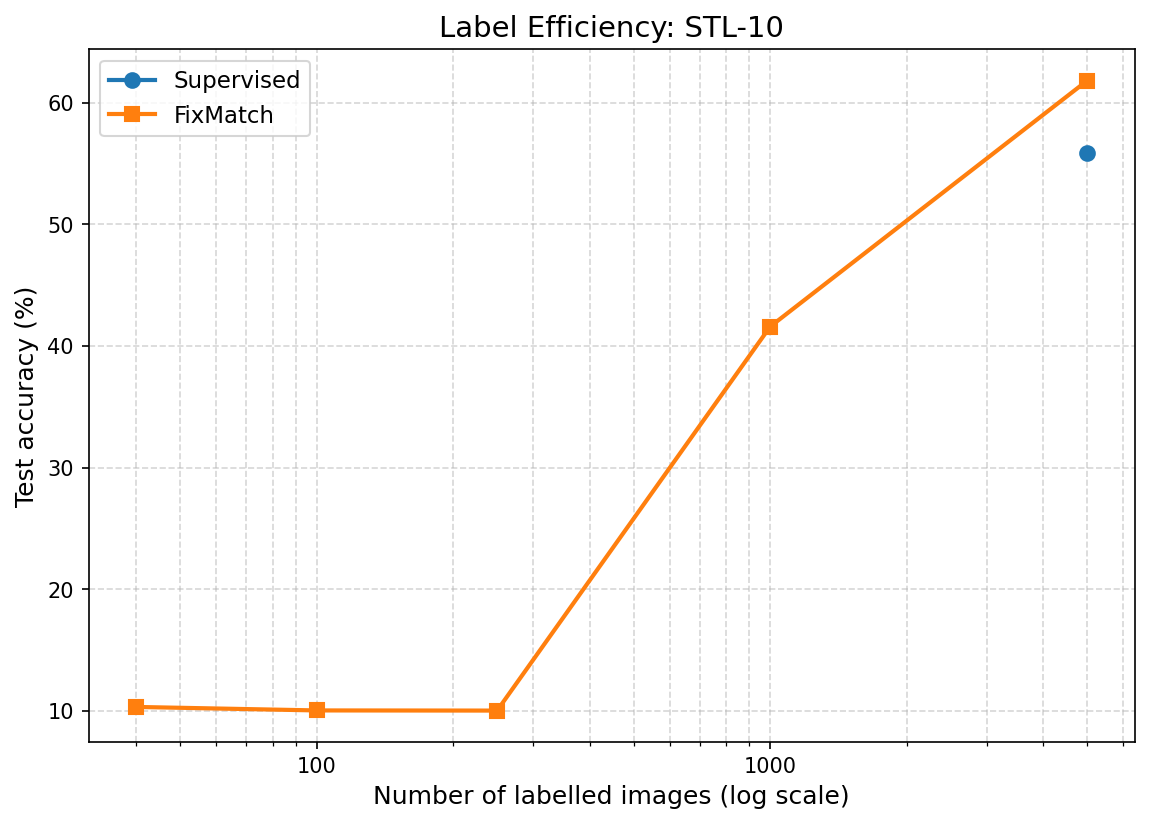

In [15]:
from IPython.display import Image
save_path = f'{PLOTS_DIR}label_efficiency.png'
plot_label_efficiency_curve({k: v for k, v in results.items() if v}, save_path=save_path)
Image(save_path)

## 9. Export best model to ONNX

In [16]:
best_acc, best_ckpt = 0.0, None
for ckpt in sorted(Path(CHECKPOINT_DIR).glob('*.pt')):
    try:
        m = ResNet18Classifier(num_classes=NUM_CLASSES)
        m.load_state_dict(torch.load(ckpt, map_location='cpu'))
        acc = evaluate(m, test_loader).accuracy
        print(f'  {ckpt.name}: {acc:.4f}')
        if acc > best_acc:
            best_acc, best_ckpt = acc, str(ckpt)
    except Exception as e:
        print(f'  {ckpt.name}: skip ({e})')

if best_ckpt:
    onnx_out = '/kaggle/working/best_model.onnx'
    export_onnx(best_ckpt, onnx_out, num_classes=NUM_CLASSES, input_size=INPUT_SIZE)
    print(f'Best: {Path(best_ckpt).name}  acc={best_acc:.4f}  -> {onnx_out}')

  fixmatch_best.pt: 0.4446
  fixmatch_n10.pt: 0.1003
  fixmatch_n100.pt: 0.4160
  fixmatch_n25.pt: 0.1001
  fixmatch_n4.pt: 0.1031
  fixmatch_n500.pt: 0.6184
  supervised_best.pt: 0.5606


/usr/local/lib/python3.12/dist-packages/semi_supervised_image_clf/export.py:40: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0406 19:48:35.242000 55 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0406 19:48:36.334000 55 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float

[torch.onnx] Obtain model graph for `ResNet18Classifier([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ResNet18Classifier([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).
Failed to convert the model to the target version 17 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 41 of general pattern rewrite rules.


2026-04-06 19:48:39.544 | INFO     | semi_supervised_image_clf.export:export_onnx:49 - ONNX model exported to /kaggle/working/best_model.onnx
2026-04-06 19:48:39.773 | INFO     | semi_supervised_image_clf.export:export_onnx:54 - ONNX model check passed.
2026-04-06 19:48:40.057 | INFO     | semi_supervised_image_clf.export:export_onnx:64 - Max output difference (PyTorch vs ONNX): 0.000002
2026-04-06 19:48:40.058 | INFO     | semi_supervised_image_clf.export:export_onnx:66 - ONNX validation passed.


Best: fixmatch_n500.pt  acc=0.6184  -> /kaggle/working/best_model.onnx
